# Customer Churn Prediction

The Customer Churn table contains information on all 7,043 customers from a Telecommunications company in California in Q2 2022


Each record represents one customer, and contains details about their demographics, location, tenure, subscription services, status for the quarter (joined, stayed, or churned), and more!

The Zip Code Population table contains complimentary information on the estimated populations for the California zip codes in the Customer Churn table

Importing necessary files

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('../Datasets/telecom_customer_churn.csv')

In [3]:
df.head(5)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


Overviewing all the columns in the dataset

In [4]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='str')

In [5]:
df1 = df.copy()

Creating a copy of the Dataset

In [6]:
df1.head(7)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,...,Credit Card,69.4,571.45,0.00,0,150.93,722.38,Stayed,NaN,NaN
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,...,Bank Withdrawal,109.7,7904.25,0.00,0,707.16,8611.41,Stayed,NaN,NaN


In [7]:
df1.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='str')

# Exploratory Data Analysis

## Data Preprocessing

Dropping unwanted columns from the dataset

In [8]:
df1.drop(['Customer ID','Total Refunds','Zip Code','Latitude', 'Longitude','Churn Category', 'Churn Reason'],axis='columns',inplace=True)


In [9]:
df1.shape

(7043, 31)

In [10]:
df1.dtypes

Gender                                   str
Age                                    int64
Married                                  str
Number of Dependents                   int64
City                                     str
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                    str
Phone Service                            str
Avg Monthly Long Distance Charges    float64
Multiple Lines                           str
Internet Service                         str
Internet Type                            str
Avg Monthly GB Download              float64
Online Security                          str
Online Backup                            str
Device Protection Plan                   str
Premium Tech Support                     str
Streaming TV                             str
Streaming Movies                         str
Streaming Music                          str
Unlimited Data                           str
Contract  

Checking the number of unique values in each column

In [11]:
features = df1.columns
for feature in features:
     print(f'{feature}--->{df[feature].nunique()}')

Gender--->2
Age--->62
Married--->2
Number of Dependents--->10
City--->1106
Number of Referrals--->12
Tenure in Months--->72
Offer--->5
Phone Service--->2
Avg Monthly Long Distance Charges--->3583
Multiple Lines--->2
Internet Service--->2
Internet Type--->3
Avg Monthly GB Download--->49
Online Security--->2
Online Backup--->2
Device Protection Plan--->2
Premium Tech Support--->2
Streaming TV--->2
Streaming Movies--->2
Streaming Music--->2
Unlimited Data--->2
Contract--->3
Paperless Billing--->2
Payment Method--->3
Monthly Charge--->1591
Total Charges--->6540
Total Extra Data Charges--->16
Total Long Distance Charges--->6068
Total Revenue--->6975
Customer Status--->3


Getting the percentge of Null Values in each Column

In [12]:
df1.isnull().sum() / df1.shape[0]

Gender                               0.000000
Age                                  0.000000
Married                              0.000000
Number of Dependents                 0.000000
City                                 0.000000
Number of Referrals                  0.000000
Tenure in Months                     0.000000
Offer                                0.550476
Phone Service                        0.000000
Avg Monthly Long Distance Charges    0.096834
Multiple Lines                       0.096834
Internet Service                     0.000000
Internet Type                        0.216669
Avg Monthly GB Download              0.216669
Online Security                      0.216669
Online Backup                        0.216669
Device Protection Plan               0.216669
Premium Tech Support                 0.216669
Streaming TV                         0.216669
Streaming Movies                     0.216669
Streaming Music                      0.216669
Unlimited Data                    

Cleaning Function for the Dataset

In [13]:
def clean_dataset(df):
    assert isinstance(df, pd.DataFrame)
    df.dropna(inplace=True)
    indices_to_keep = ~df.isin([np.nan, np.inf, -np.inf]).any(1)
    return df[indices_to_keep].astype(np.float64)

In [14]:
df1.dtypes

Gender                                   str
Age                                    int64
Married                                  str
Number of Dependents                   int64
City                                     str
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                    str
Phone Service                            str
Avg Monthly Long Distance Charges    float64
Multiple Lines                           str
Internet Service                         str
Internet Type                            str
Avg Monthly GB Download              float64
Online Security                          str
Online Backup                            str
Device Protection Plan                   str
Premium Tech Support                     str
Streaming TV                             str
Streaming Movies                         str
Streaming Music                          str
Unlimited Data                           str
Contract  

In [15]:
df1.isnull().sum()

Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                     1526
Streaming Music                      1526
Unlimited Data                       1526
Contract                                0
Paperless Billing                 

In [16]:
# Fill numeric columns
num_cols = df1.select_dtypes(include=['int64', 'float64']).columns
df1[num_cols] = df1[num_cols].fillna(df1[num_cols].median())

# Fill categorical columns
cat_cols = df1.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df1[col] = df1[col].fillna(df1[col].mode()[0])

In [17]:
df1=df1.dropna()
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [18]:
df['Unlimited Data'] 

0       Yes
1        No
2       Yes
3       Yes
4       Yes
       ... 
7038    Yes
7039    Yes
7040    Yes
7041    Yes
7042    Yes
Name: Unlimited Data, Length: 7043, dtype: str

In [19]:
number_columns=['Age','Number of Dependents','Number of Referrals','Tenure in Months','Avg Monthly Long Distance Charges','Avg Monthly GB Download','Monthly Charge','Total Charges','Total Extra Data Charges','Total Long Distance Charges','Total Revenue']

Checking the unique values of column having datatype: 'object'

In [20]:
def unique_values_names(df):
    for column in df:
        if df[column].dtype=='object':
            print(f'{column}:{df[column].unique()}')

In [21]:
unique_values_names(df1)

# Data Visualization

In [22]:
import plotly.express as px 

Visualizing Column 'Age' in the dataset

In [23]:
fig = px.histogram(df1, x = 'Age')
fig.show()

Checking the stats in number_columns of the copied dataset

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Number of Dependents'}>,
        <Axes: title={'center': 'Number of Referrals'}>],
       [<Axes: title={'center': 'Tenure in Months'}>,
        <Axes: title={'center': 'Avg Monthly Long Distance Charges'}>,
        <Axes: title={'center': 'Avg Monthly GB Download'}>],
       [<Axes: title={'center': 'Monthly Charge'}>,
        <Axes: title={'center': 'Total Charges'}>,
        <Axes: title={'center': 'Total Extra Data Charges'}>],
       [<Axes: title={'center': 'Total Long Distance Charges'}>,
        <Axes: title={'center': 'Total Revenue'}>, <Axes: >]],
      dtype=object)

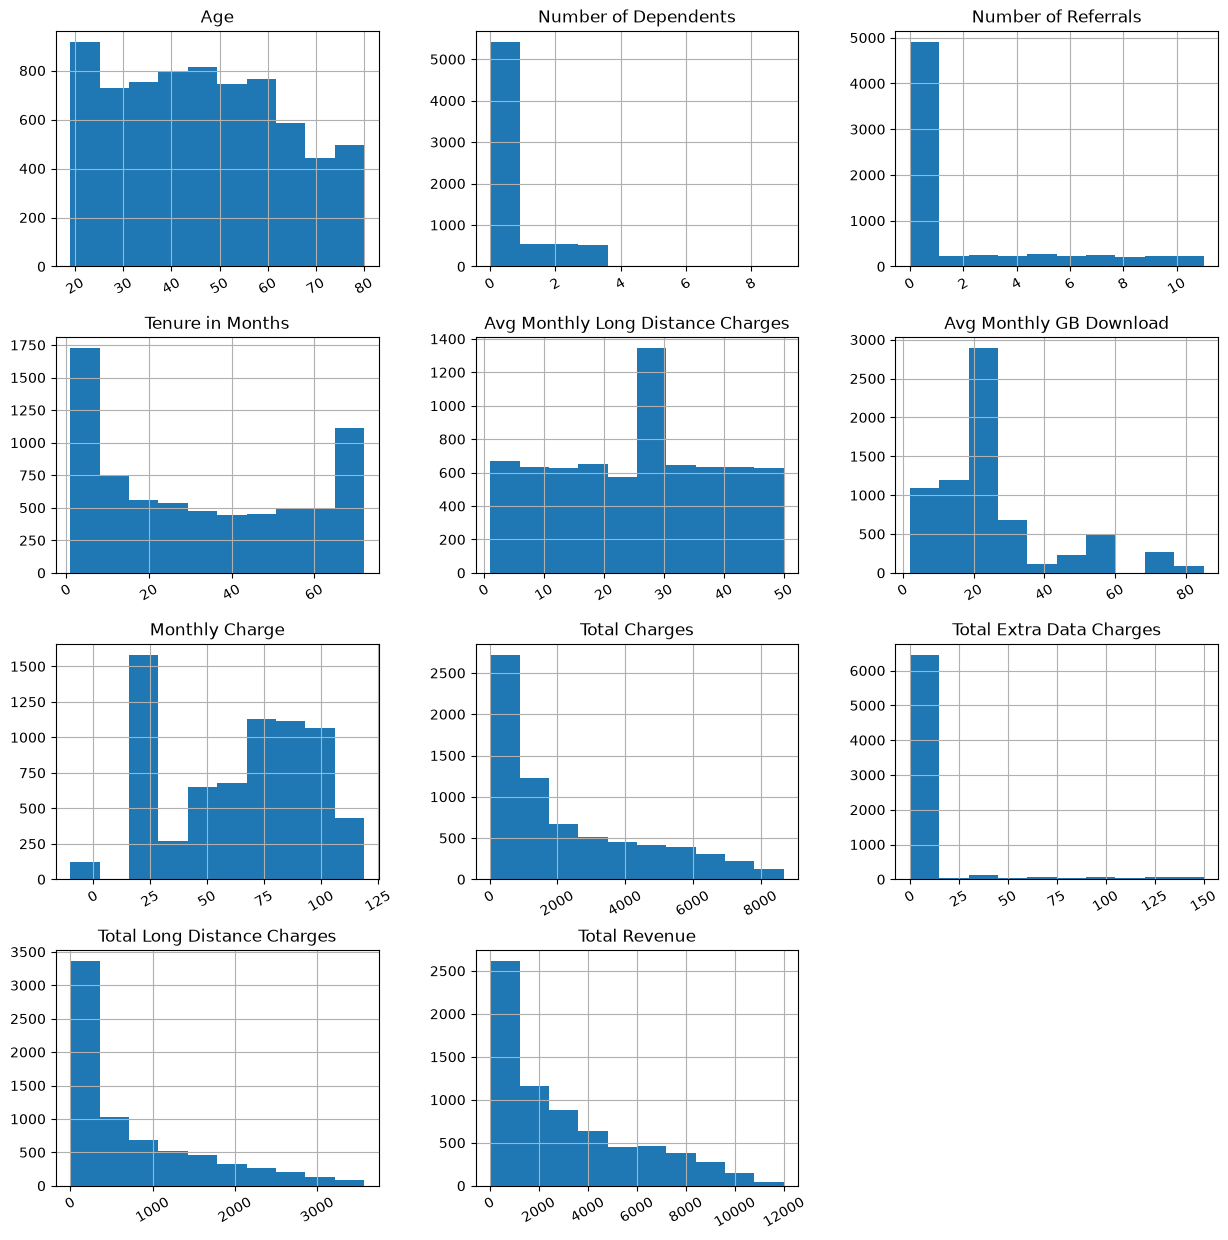

In [24]:
df1.hist(figsize=(15,15), xrot=30)

In [25]:
df1['Age']


0       37
1       46
2       50
3       78
4       75
        ..
7038    20
7039    40
7040    22
7041    21
7042    36
Name: Age, Length: 7043, dtype: int64

In [26]:
import matplotlib.pyplot as plt

Visualizing the number of customers who churned, stayed or joined in the company with a bar plot

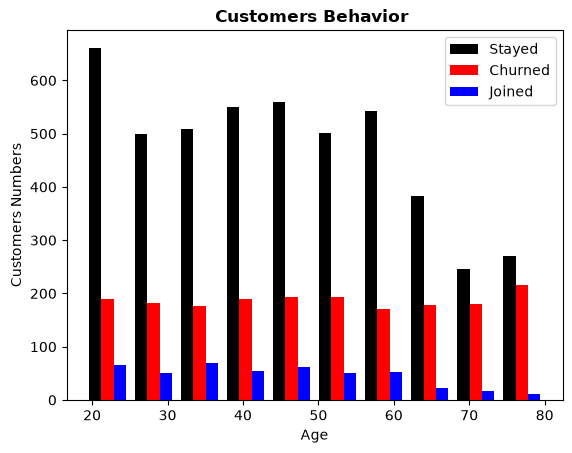

In [27]:
Customer_Stayed=df1[df1['Customer Status']=='Stayed'].Age
Customer_Churned=df1[df1['Customer Status']=='Churned'].Age
Customer_Joined=df1[df1['Customer Status']=='Joined'].Age

plt.xlabel('Age')
plt.ylabel('Customers Numbers')
plt.hist([Customer_Stayed,Customer_Churned,Customer_Joined], color=['black','red','blue'],label=['Stayed','Churned','Joined'])

plt.title('Customers Behavior ',fontweight ="bold")
plt.legend()

In [28]:
import seaborn as sns

 ## Defining Correlation between the columns in the dataset

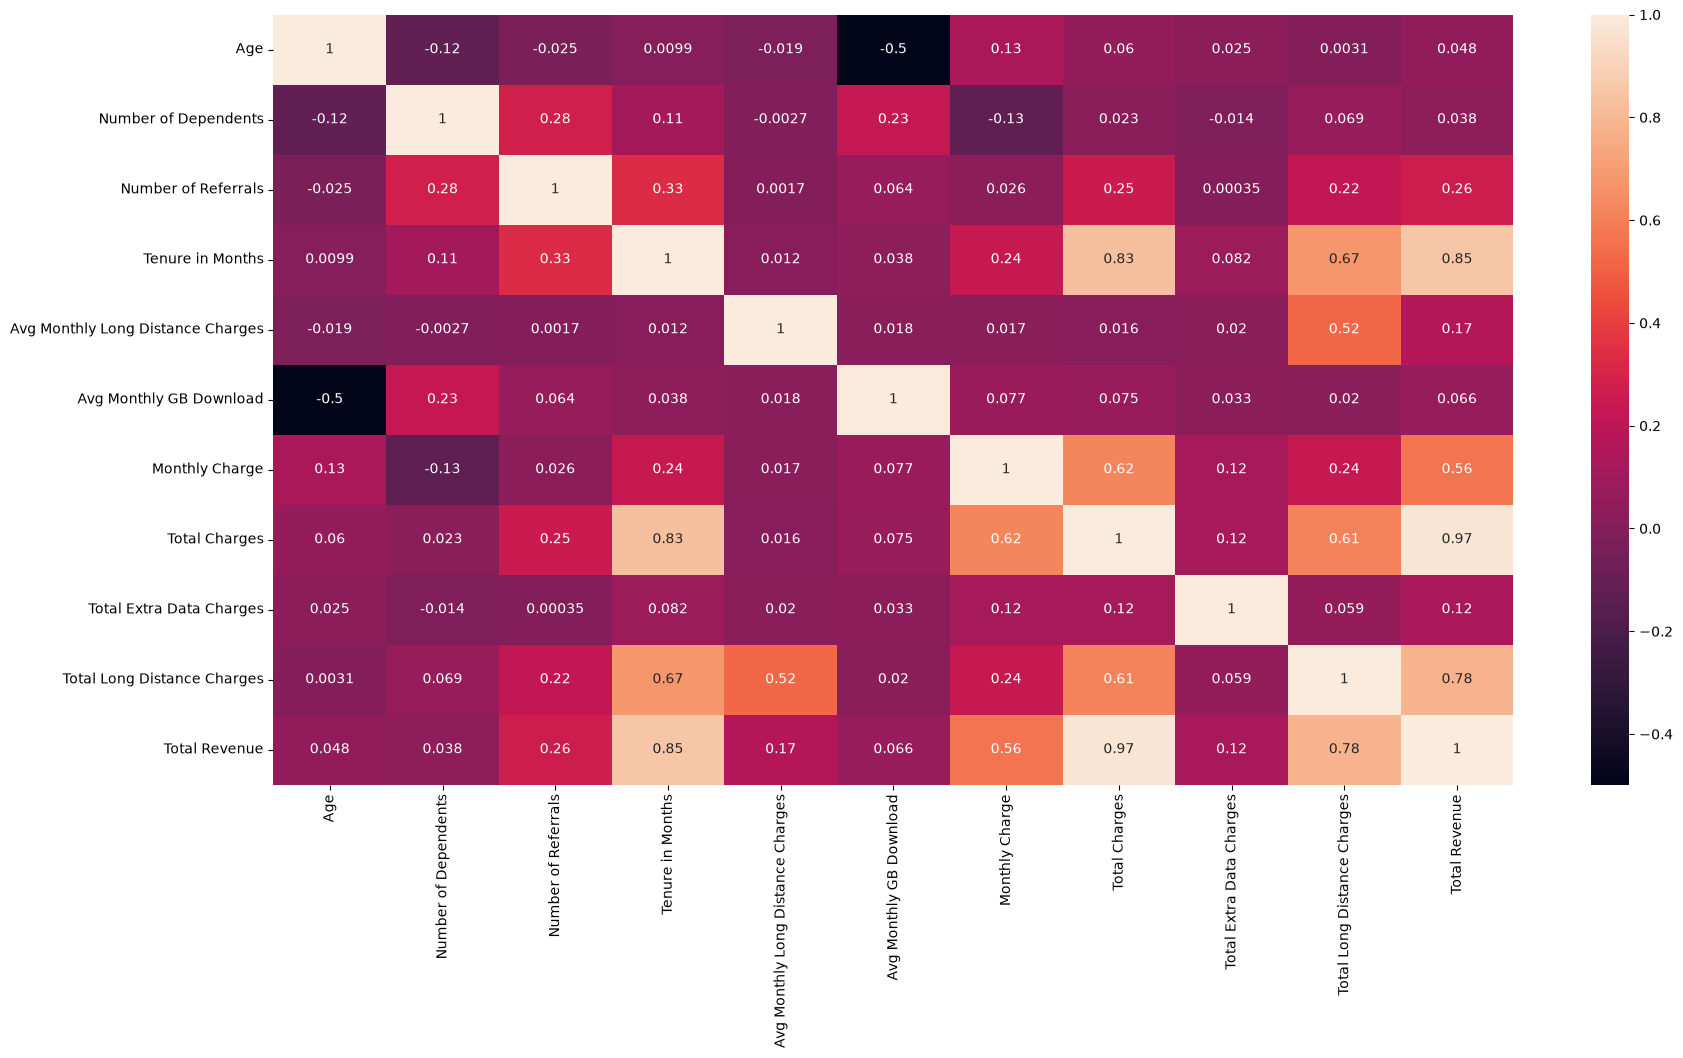

In [29]:
data = df1.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(20,10))
sns.heatmap(data, annot=True)
plt.show()

Analyzing Outlier in the dataset with respect to customer status

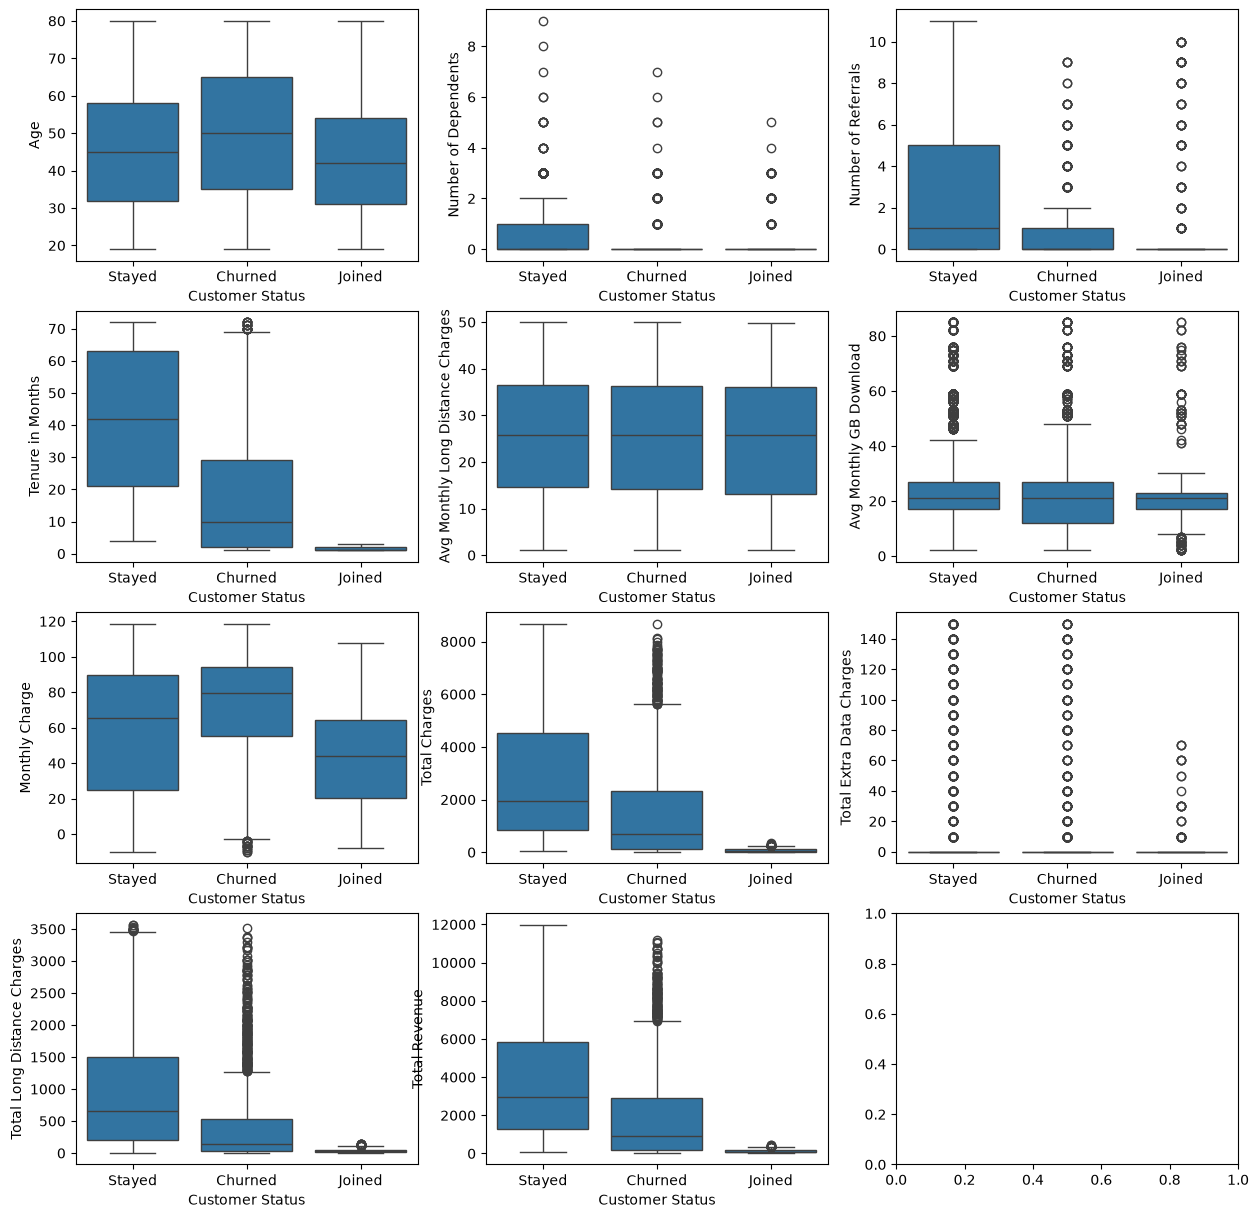

In [30]:
fig, ax = plt.subplots(4,3, figsize = (15,15))
for i, subplot in zip(number_columns, ax.flatten()):
    sns.boxplot(x = 'Customer Status', y = i , data = df1, ax = subplot)

In [31]:
fig = px.density_heatmap(df1, x='Age', y='Total Charges')
fig.show()

In [32]:
df1.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'City',
       'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status'],
      dtype='str')

<Axes: xlabel='Customer Status'>

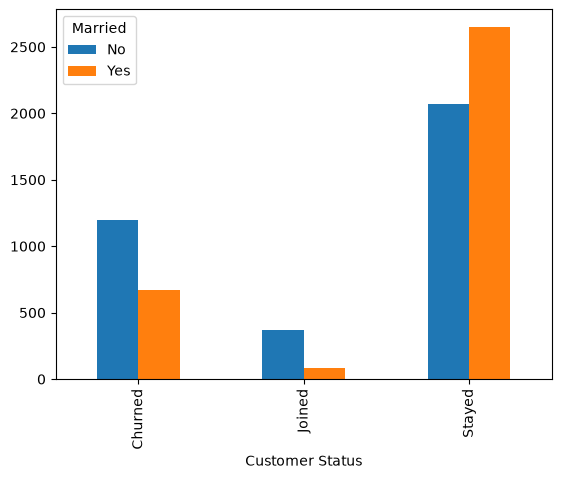

In [33]:
pd.crosstab(df['Customer Status'], df['Married']).plot(kind='bar')

<Axes: xlabel='Customer Status'>

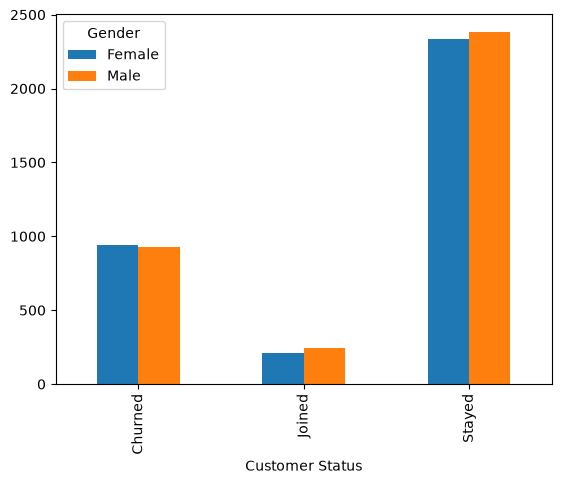

In [34]:
pd.crosstab(df['Customer Status'], df['Gender']).plot(kind='bar')

In [35]:
df1['Payment Method'].unique()

<StringArray>
['Credit Card', 'Bank Withdrawal', 'Mailed Check']
Length: 3, dtype: str

Create dictionary with role / data key value pairs

In [36]:
Roles = {}
for j in df1['Payment Method'].unique():
    Roles[j] = df1[df1['Payment Method'] == j]

In [37]:
Roles.keys()

dict_keys(['Credit Card', 'Bank Withdrawal', 'Mailed Check'])

Selecting the rows where the role is 'Credit Card'

In [38]:
Roles['Credit Card']

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,Female,37,Yes,0,Frazier Park,2,9,Offer B,Yes,42.39,...,Yes,One Year,Yes,Credit Card,65.60,593.30,0,381.51,974.81,Stayed
1,Male,46,No,0,Glendale,0,9,Offer B,Yes,10.69,...,No,Month-to-Month,No,Credit Card,-4.00,542.40,10,96.21,610.28,Stayed
4,Female,75,Yes,0,Camarillo,3,3,Offer B,Yes,7.38,...,Yes,Month-to-Month,Yes,Credit Card,83.90,267.40,0,22.14,289.54,Churned
5,Female,23,No,3,Midpines,0,9,Offer E,Yes,16.77,...,Yes,Month-to-Month,Yes,Credit Card,69.40,571.45,0,150.93,722.38,Stayed
7,Male,52,Yes,0,Napa,8,63,Offer B,Yes,12.96,...,No,Two Year,Yes,Credit Card,84.65,5377.80,20,816.48,6214.28,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,Female,20,No,0,Los Angeles,0,7,Offer E,Yes,36.49,...,Yes,One Year,Yes,Credit Card,94.05,633.45,0,255.43,888.88,Stayed
7036,Female,53,No,0,Hume,0,1,Offer E,Yes,42.09,...,Yes,Month-to-Month,Yes,Credit Card,70.15,70.15,0,42.09,112.24,Churned
7038,Female,20,No,0,La Mesa,0,13,Offer D,Yes,46.68,...,Yes,One Year,No,Credit Card,55.15,742.90,0,606.84,1349.74,Stayed
7040,Male,22,No,0,Elk,0,2,Offer E,Yes,18.62,...,Yes,Month-to-Month,Yes,Credit Card,50.30,92.75,0,37.24,129.99,Joined


In [39]:
len(Roles)


3

Checking the number of Offers in the dataset

In [40]:
off = df1['Offer'].value_counts()
off


Offer
Offer B    4701
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

In [41]:
import plotly.graph_objects as go

In [42]:
fig = go.Figure([go.Bar(x=off.index, y=off.values)])
fig.show()

In [43]:
df1_off = Roles['Credit Card'].Offer.value_counts()
df1_off

Offer
Offer B    1828
Offer E     267
Offer D     251
Offer A     239
Offer C     164
Name: count, dtype: int64

In [44]:
fig = go.Figure([go.Bar(x= df1_off.index, y=df1_off.values)])
fig.show()

In [45]:
df1 = df1.rename(columns = {'Customer Status':'Customer_Status'})

In [46]:
Roles1 = {}
for k in df1['Customer_Status'].unique():
    Roles1[k] = df1[df1['Customer_Status'] == k]
Roles1.keys()

dict_keys(['Stayed', 'Churned', 'Joined'])

In [47]:
df1_state = Roles1['Stayed'].Offer.value_counts()
df1_state

Offer
Offer B    3270
Offer A     485
Offer D     441
Offer C     320
Offer E     204
Name: count, dtype: int64

# Data Modelling

Replacing the Gender column in the dataset with Label Encoding

0 for Female

1 for Male

In [48]:
df1.replace({"Gender":{'Female':0,'Male':1}},inplace=True)

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer_Status
0,0,37,Yes,0,Frazier Park,2,9,Offer B,Yes,42.39,...,Yes,One Year,Yes,Credit Card,65.60,593.30,0,381.51,974.81,Stayed
1,1,46,No,0,Glendale,0,9,Offer B,Yes,10.69,...,No,Month-to-Month,No,Credit Card,-4.00,542.40,10,96.21,610.28,Stayed
2,1,50,No,0,Costa Mesa,0,4,Offer E,Yes,33.65,...,Yes,Month-to-Month,Yes,Bank Withdrawal,73.90,280.85,0,134.60,415.45,Churned
3,1,78,Yes,0,Martinez,1,13,Offer D,Yes,27.82,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.00,1237.85,0,361.66,1599.51,Churned
4,0,75,Yes,0,Camarillo,3,3,Offer B,Yes,7.38,...,Yes,Month-to-Month,Yes,Credit Card,83.90,267.40,0,22.14,289.54,Churned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,20,No,0,La Mesa,0,13,Offer D,Yes,46.68,...,Yes,One Year,No,Credit Card,55.15,742.90,0,606.84,1349.74,Stayed
7039,1,40,Yes,0,Riverbank,1,22,Offer D,Yes,16.20,...,Yes,Month-to-Month,Yes,Bank Withdrawal,85.10,1873.70,0,356.40,2230.10,Churned
7040,1,22,No,0,Elk,0,2,Offer E,Yes,18.62,...,Yes,Month-to-Month,Yes,Credit Card,50.30,92.75,0,37.24,129.99,Joined
7041,1,21,Yes,0,Solana Beach,5,67,Offer A,Yes,2.12,...,Yes,Two Year,No,Credit Card,67.85,4627.65,0,142.04,4769.69,Stayed


Replacing the columns with 'yes' and 'no' output by Label Encoding

0 for No

1 for Yes

In [49]:
yes_and_no=[  'Paperless Billing', 'Unlimited Data', 
       'Streaming Movies', 'Streaming Music',  'Streaming TV',
       'Premium Tech Support', 'Device Protection Plan', 'Online Backup', 'Online Security',
       'Multiple Lines',  'Married']
for i in yes_and_no:
    df1.replace({'No':0,'Yes':1},inplace=True)

Replacing 'Phone Service' with '1'

In [50]:
df1.replace({"Phone Service":{'Yes':1}},inplace=True)

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer_Status
0,0,37,1,0,Frazier Park,2,9,Offer B,1,42.39,...,1,One Year,1,Credit Card,65.60,593.30,0,381.51,974.81,Stayed
1,1,46,0,0,Glendale,0,9,Offer B,1,10.69,...,0,Month-to-Month,0,Credit Card,-4.00,542.40,10,96.21,610.28,Stayed
2,1,50,0,0,Costa Mesa,0,4,Offer E,1,33.65,...,1,Month-to-Month,1,Bank Withdrawal,73.90,280.85,0,134.60,415.45,Churned
3,1,78,1,0,Martinez,1,13,Offer D,1,27.82,...,1,Month-to-Month,1,Bank Withdrawal,98.00,1237.85,0,361.66,1599.51,Churned
4,0,75,1,0,Camarillo,3,3,Offer B,1,7.38,...,1,Month-to-Month,1,Credit Card,83.90,267.40,0,22.14,289.54,Churned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,20,0,0,La Mesa,0,13,Offer D,1,46.68,...,1,One Year,0,Credit Card,55.15,742.90,0,606.84,1349.74,Stayed
7039,1,40,1,0,Riverbank,1,22,Offer D,1,16.20,...,1,Month-to-Month,1,Bank Withdrawal,85.10,1873.70,0,356.40,2230.10,Churned
7040,1,22,0,0,Elk,0,2,Offer E,1,18.62,...,1,Month-to-Month,1,Credit Card,50.30,92.75,0,37.24,129.99,Joined
7041,1,21,1,0,Solana Beach,5,67,Offer A,1,2.12,...,1,Two Year,0,Credit Card,67.85,4627.65,0,142.04,4769.69,Stayed


In [51]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1.Customer_Status = le.fit_transform(df1.Customer_Status)


In [52]:
df1 = pd.get_dummies(data=df1, columns=['Payment Method','Contract','Internet Type','Offer','City'])


In [53]:
cols_to_scale = ['Age','Number of Dependents','Number of Referrals','Tenure in Months','Avg Monthly Long Distance Charges','Avg Monthly GB Download','Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges','Total Revenue']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df1[cols_to_scale] = scaler.fit_transform(df1[cols_to_scale])

## Dealing with Imbalance Data

Dropping the Customer_Status

i.e. The column tht we have to predict and set as a dependent variable

In [54]:
X = df1.drop('Customer_Status',axis='columns')
y = df1['Customer_Status']

In [55]:
X.head(5)

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yorkville,City_Yountville,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley,City_Zenia
0,0,0.295082,1,0.0,0.181818,0.112676,1,0.844835,0,1,...,False,False,False,False,False,False,False,False,False,False
1,1,0.442623,0,0.0,0.000000,0.112676,1,0.197632,1,1,...,False,False,False,False,False,False,False,False,False,False
2,1,0.508197,0,0.0,0.000000,0.042254,1,0.666394,0,1,...,False,False,False,False,False,False,False,False,False,False
3,1,0.967213,1,0.0,0.090909,0.169014,1,0.547366,0,1,...,False,False,False,False,False,False,False,False,False,False
4,0,0.918033,1,0.0,0.272727,0.028169,1,0.130053,0,1,...,False,False,False,False,False,False,False,False,False,False


In [56]:
y.head(5)


0    2
1    2
2    0
3    0
4    0
Name: Customer_Status, dtype: int64

# Data Model Building

## Spliiting the data in Training and Test Data

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=5)

In [58]:
len(X_train)

5634

In [59]:
X_train[:10]

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yorkville,City_Yountville,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley,City_Zenia
5860,1,0.327869,0,0.000000,0.000000,0.591549,1,0.569416,1,0,...,False,False,False,False,False,False,False,False,False,False
2458,1,0.573770,0,0.000000,0.000000,0.464789,1,0.397305,1,0,...,False,False,False,False,False,False,False,False,False,False
5879,1,0.442623,1,0.000000,0.181818,1.000000,1,0.955696,1,1,...,False,False,False,False,False,False,False,False,False,False
4708,1,0.459016,0,0.000000,0.000000,0.056338,1,0.128624,0,1,...,False,False,False,False,False,False,False,False,False,False
1293,0,0.704918,1,0.000000,0.090909,0.084507,1,0.440996,1,1,...,False,False,False,False,False,False,False,False,False,False
2242,1,0.311475,1,0.000000,0.727273,0.929577,1,0.552266,1,1,...,False,False,False,False,False,False,False,False,False,False
1444,0,0.459016,0,0.333333,0.000000,0.464789,1,0.651899,0,1,...,False,False,False,False,False,False,False,False,False,False
3269,1,0.573770,0,0.000000,0.000000,0.154930,1,0.914455,1,1,...,False,False,False,False,False,False,False,False,False,False
101,1,0.573770,1,0.111111,0.636364,0.647887,1,0.001633,1,1,...,False,False,False,False,False,False,False,False,False,False
4191,0,0.213115,0,0.333333,0.000000,0.000000,1,0.247448,0,1,...,False,False,False,False,False,False,False,False,False,False


Importing the required files for the model that is to applied

1. Random Forest Classifier
2. Logistic Regression
3. GaussianNB
4. Decision Tree Classifier
5. XGB Classifier


## Importing Models

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

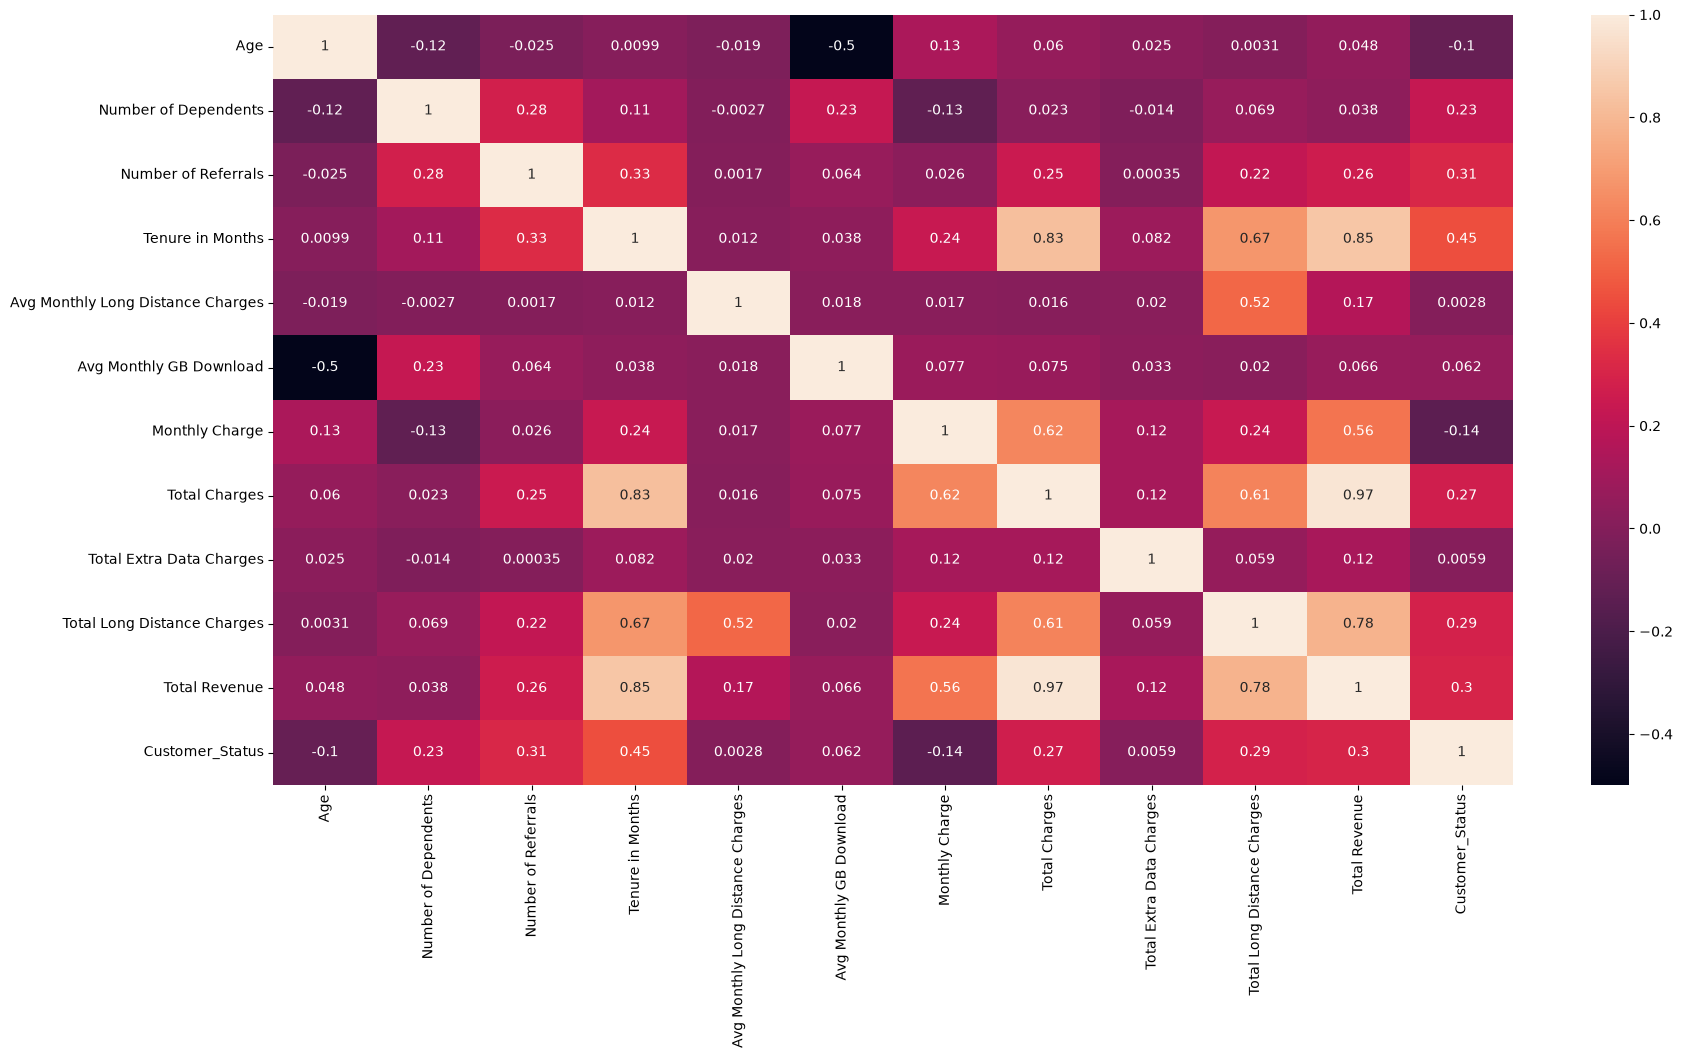

In [61]:
data = df1.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(20,10))
sns.heatmap(data, annot=True)
plt.show()

In [62]:
from sklearn.model_selection import ShuffleSplit

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

model_params = {
    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [1, 5, 10]
        }
    },
    'logistic_regression': {
    'model': LogisticRegression(solver='lbfgs', max_iter=1000),
    'params': {
        'C': [1,5,10]
    }
    },
    'naive_bayes': {
        'model': GaussianNB(),
        'params': {}
    },
    'decision_tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini', 'entropy']
        }
    }
}

In [64]:
print("model_params" in globals())

True


Getting the best_score from the applied models

In [ ]:
from sklearn.model_selection import GridSearchCV
scores = []
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
for model_name, mp in model_params.items():
    clf =  GridSearchCV(mp['model'], mp['params'], cv=cv, return_train_score=False)
    clf.fit(X,y)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

It was concluded that XGB_Classifier was giving us the best_score in the dataset

## Selecting the model with best score for the dataset

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df1.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded.head()

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yorkville,City_Yountville,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley,City_Zenia
0,0,0.295082,1,0.0,0.181818,0.112676,1,0.844835,0,1,...,False,False,False,False,False,False,False,False,False,False
1,1,0.442623,0,0.0,0.000000,0.112676,1,0.197632,1,1,...,False,False,False,False,False,False,False,False,False,False
2,1,0.508197,0,0.0,0.000000,0.042254,1,0.666394,0,1,...,False,False,False,False,False,False,False,False,False,False
3,1,0.967213,1,0.0,0.090909,0.169014,1,0.547366,0,1,...,False,False,False,False,False,False,False,False,False,False
4,0,0.918033,1,0.0,0.272727,0.028169,1,0.130053,0,1,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X.dtypes

Gender                   object
Age                     float64
Married                  object
Number of Dependents    float64
Number of Referrals     float64
                         ...   
City_Yreka                 bool
City_Yuba City             bool
City_Yucaipa               bool
City_Yucca Valley          bool
City_Zenia                 bool
Length: 1145, dtype: object

In [ ]:
X_train.dtypes[X_train.dtypes == 'object']

Gender                    object
Married                   object
Phone Service             object
Multiple Lines            object
Internet Service          object
Online Security           object
Online Backup             object
Device Protection Plan    object
Premium Tech Support      object
Streaming TV              object
Streaming Movies          object
Streaming Music           object
Unlimited Data            object
Paperless Billing         object
dtype: object

We got an accuracy of 80.86 percent in the testing dataset

## Predicting values from the model build to check the accuracy

In [ ]:
print(X_train.dtypes.value_counts()) 
X_train.select_dtypes(include=['object']).columns

bool       1120
object       14
float64      11
Name: count, dtype: int64


Index(['Gender', 'Married', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data',
       'Paperless Billing'],
      dtype='str')

## Verifying the actual values with the predicted values

In [ ]:
y_test[:5]

185     2
2715    2
3825    2
1807    1
132     2
Name: Customer_Status, dtype: int64

## Importing Confusion Matrx 

In [ ]:
X_train.select_dtypes(include=['object']).columns

Index(['Gender', 'Married', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data',
       'Paperless Billing'],
      dtype='str')

In [ ]:
# Convert all categorical columns into numeric columns
df_encoded = pd.get_dummies(df1, drop_first=True)

print(df_encoded.dtypes.unique())

[dtype('float64') dtype('int64') dtype('bool')]


In [ ]:
print(df_encoded.columns.tolist())

['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Customer_Status', 'Payment Method_Bank Withdrawal', 'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'Contract_Month-to-Month', 'Contract_One Year', 'Contract_Two Year', 'Internet Type_Cable', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'City_Acampo', 'City_Acton', 'City_Adelanto', 'City_Adin', 'City_Agoura Hills', 'City_Aguanga', 'City_Ahwahnee', 'City_Alameda', 'City_Alamo', 'City_Albany', 'City_Albion', 'City_Alderpoint', 'City_Alhambra', 'City_Aliso Viejo', 'City_Alleghany', 'City_Alpaugh', 'City_Alpine', 'City_Alta', 'City_Altadena', 'City_Alturas', 'City_Alviso', 'City_Amador City', 'City_Amboy', 'City_Anaheim', 'City_Anderson', 'Ci

In [ ]:
print(df_encoded.columns.tolist())

['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Customer_Status', 'Payment Method_Bank Withdrawal', 'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'Contract_Month-to-Month', 'Contract_One Year', 'Contract_Two Year', 'Internet Type_Cable', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'City_Acampo', 'City_Acton', 'City_Adelanto', 'City_Adin', 'City_Agoura Hills', 'City_Aguanga', 'City_Ahwahnee', 'City_Alameda', 'City_Alamo', 'City_Albany', 'City_Albion', 'City_Alderpoint', 'City_Alhambra', 'City_Aliso Viejo', 'City_Alleghany', 'City_Alpaugh', 'City_Alpine', 'City_Alta', 'City_Altadena', 'City_Alturas', 'City_Alviso', 'City_Amador City', 'City_Amboy', 'City_Anaheim', 'City_Anderson', 'Ci

In [ ]:
X = df_encoded.drop('Customer_Status', axis=1)
y = df_encoded['Customer_Status']

In [ ]:
print(X.select_dtypes(include=['object']).columns)

Index([], dtype='str')


In [ ]:
print(y.dtype)
print(y.unique())

int64
[2 0 1]


In [ ]:
X_train.select_dtypes(include=['object']).columns

Index(['Gender', 'Married', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data',
       'Paperless Billing'],
      dtype='str')

In [ ]:
y.unique()

array([2, 0, 1])

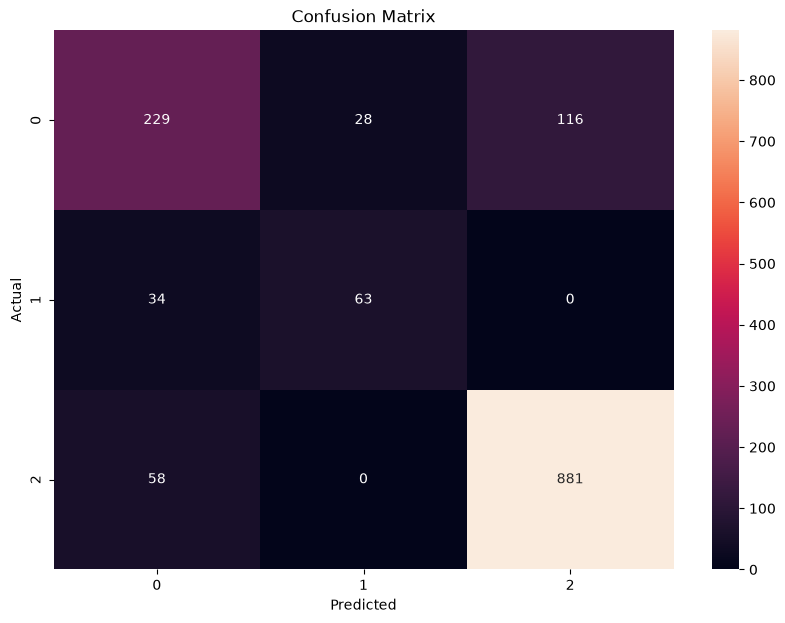

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert all columns to numeric
X_train = X_train.astype('float64')
X_test = X_test.astype('float64')

# Train model
reg = XGBClassifier()
reg.fit(X_train, y_train)

# Predict
y_predicted = reg.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_predicted)

# Plot
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Importing Classification Report

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.71      0.61      0.66       373
           1       0.69      0.65      0.67        97
           2       0.88      0.94      0.91       939

    accuracy                           0.83      1409
   macro avg       0.76      0.73      0.75      1409
weighted avg       0.83      0.83      0.83      1409



In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predicted)

0.8325053229240597

In the end we conclude that the Telecom Customer Churn Prediction was best worked with XGB_Classifier with an accuracy score of 80.86%